## OR-Tools

**Concepts:** [Exact optimization](../routers.md#exact-optimization) · [Model options](../routers.md#model-options) **Reference:** [MILP Solvers](../reference/solvers.md) **Network/Router API:** [🎯 MILPRouter](hi23_milp.ipynb)

Refining a heuristic and a meta-heuristic solution with the OR-Tools CP-SAT solver. The MILP approach and the other supported solvers are described in [Exact optimization](../routers.md#exact-optimization); the model options set below are described in [Model options](../routers.md#model-options).

In [1]:
from optiwindnet.importer import load_repository
from optiwindnet.svg import svgplot
from optiwindnet.mesh import make_planar_embedding
from optiwindnet.interarraylib import G_from_S, as_normalized
from optiwindnet.heuristics import constructor
from optiwindnet.baselines.hgs import hgs_cvrp
from optiwindnet.MILP import solver_factory, ModelOptions

### Initialize Moray East

In [2]:
locations = load_repository()

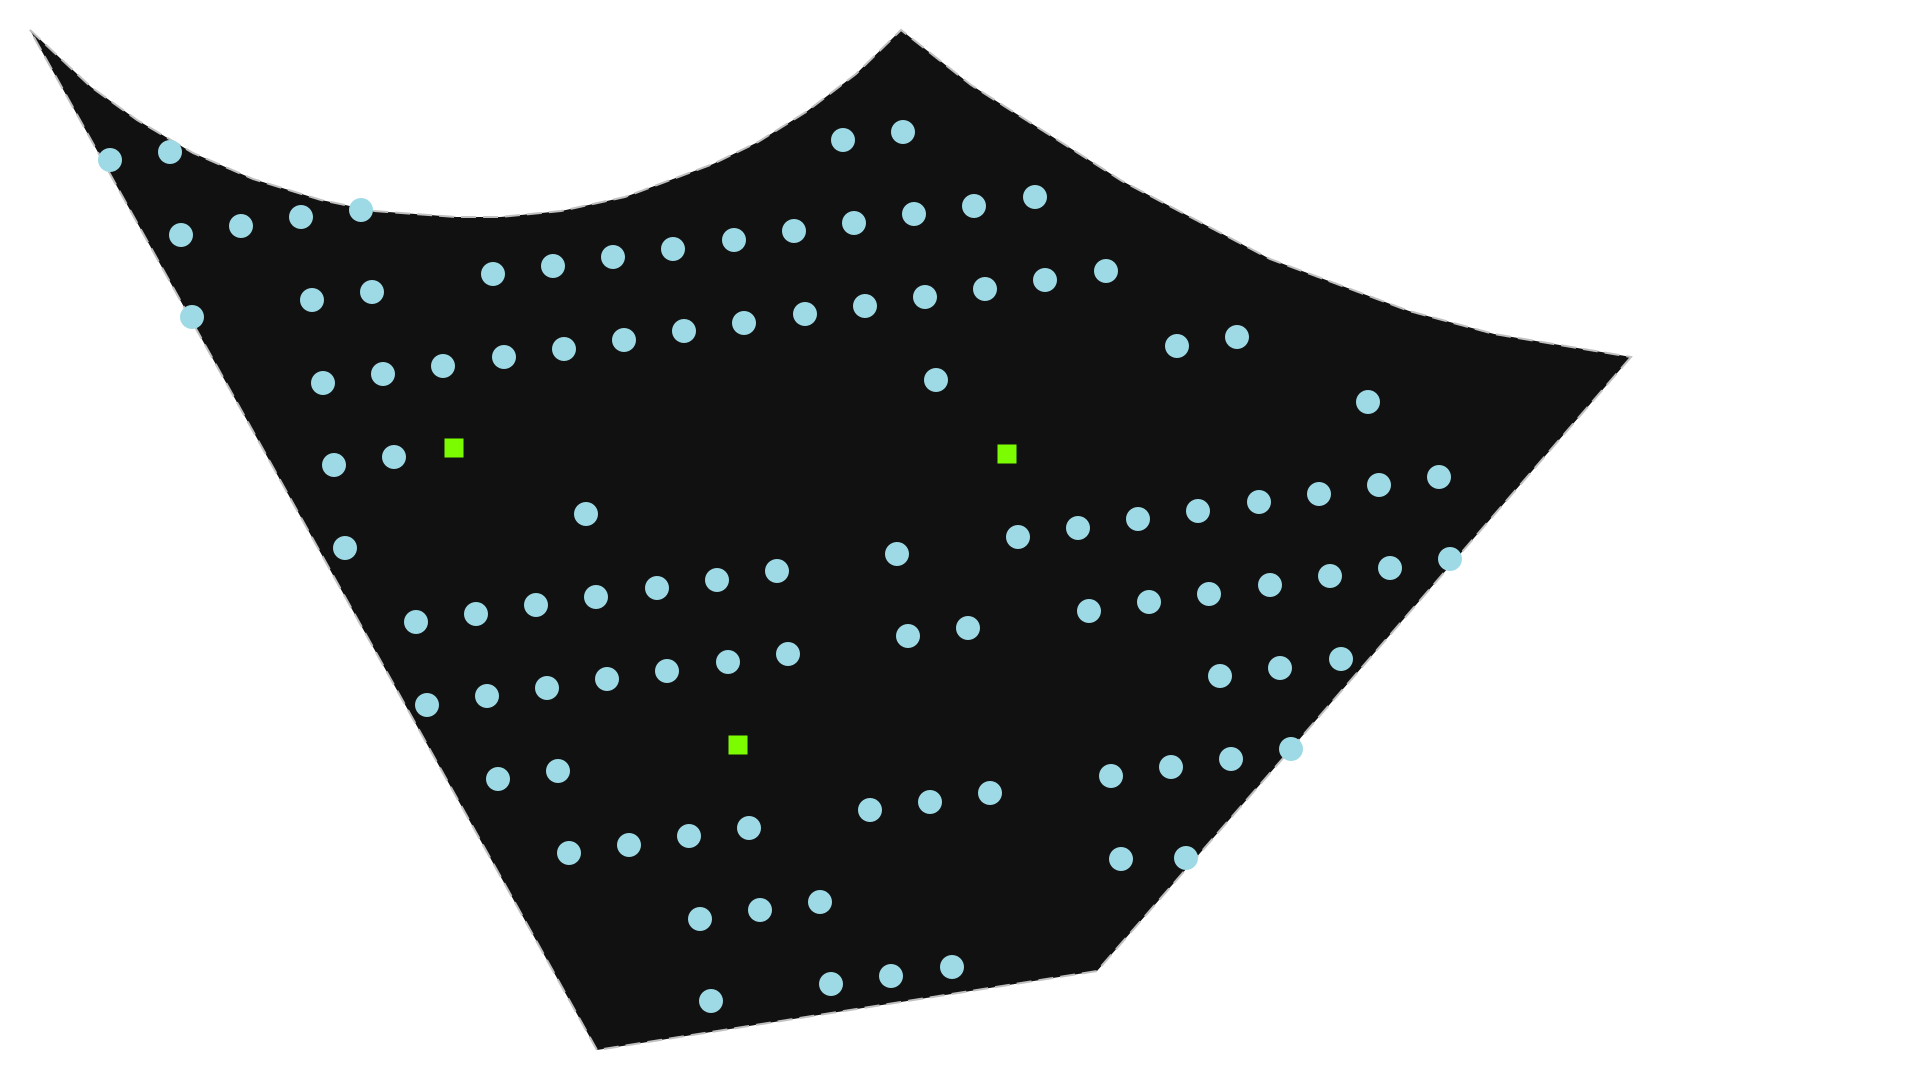

In [3]:
L = locations.morayeast
svgplot(L)

### Optimize Moray East

In [4]:
P, A = make_planar_embedding(L)

#### Get a heuristic solution

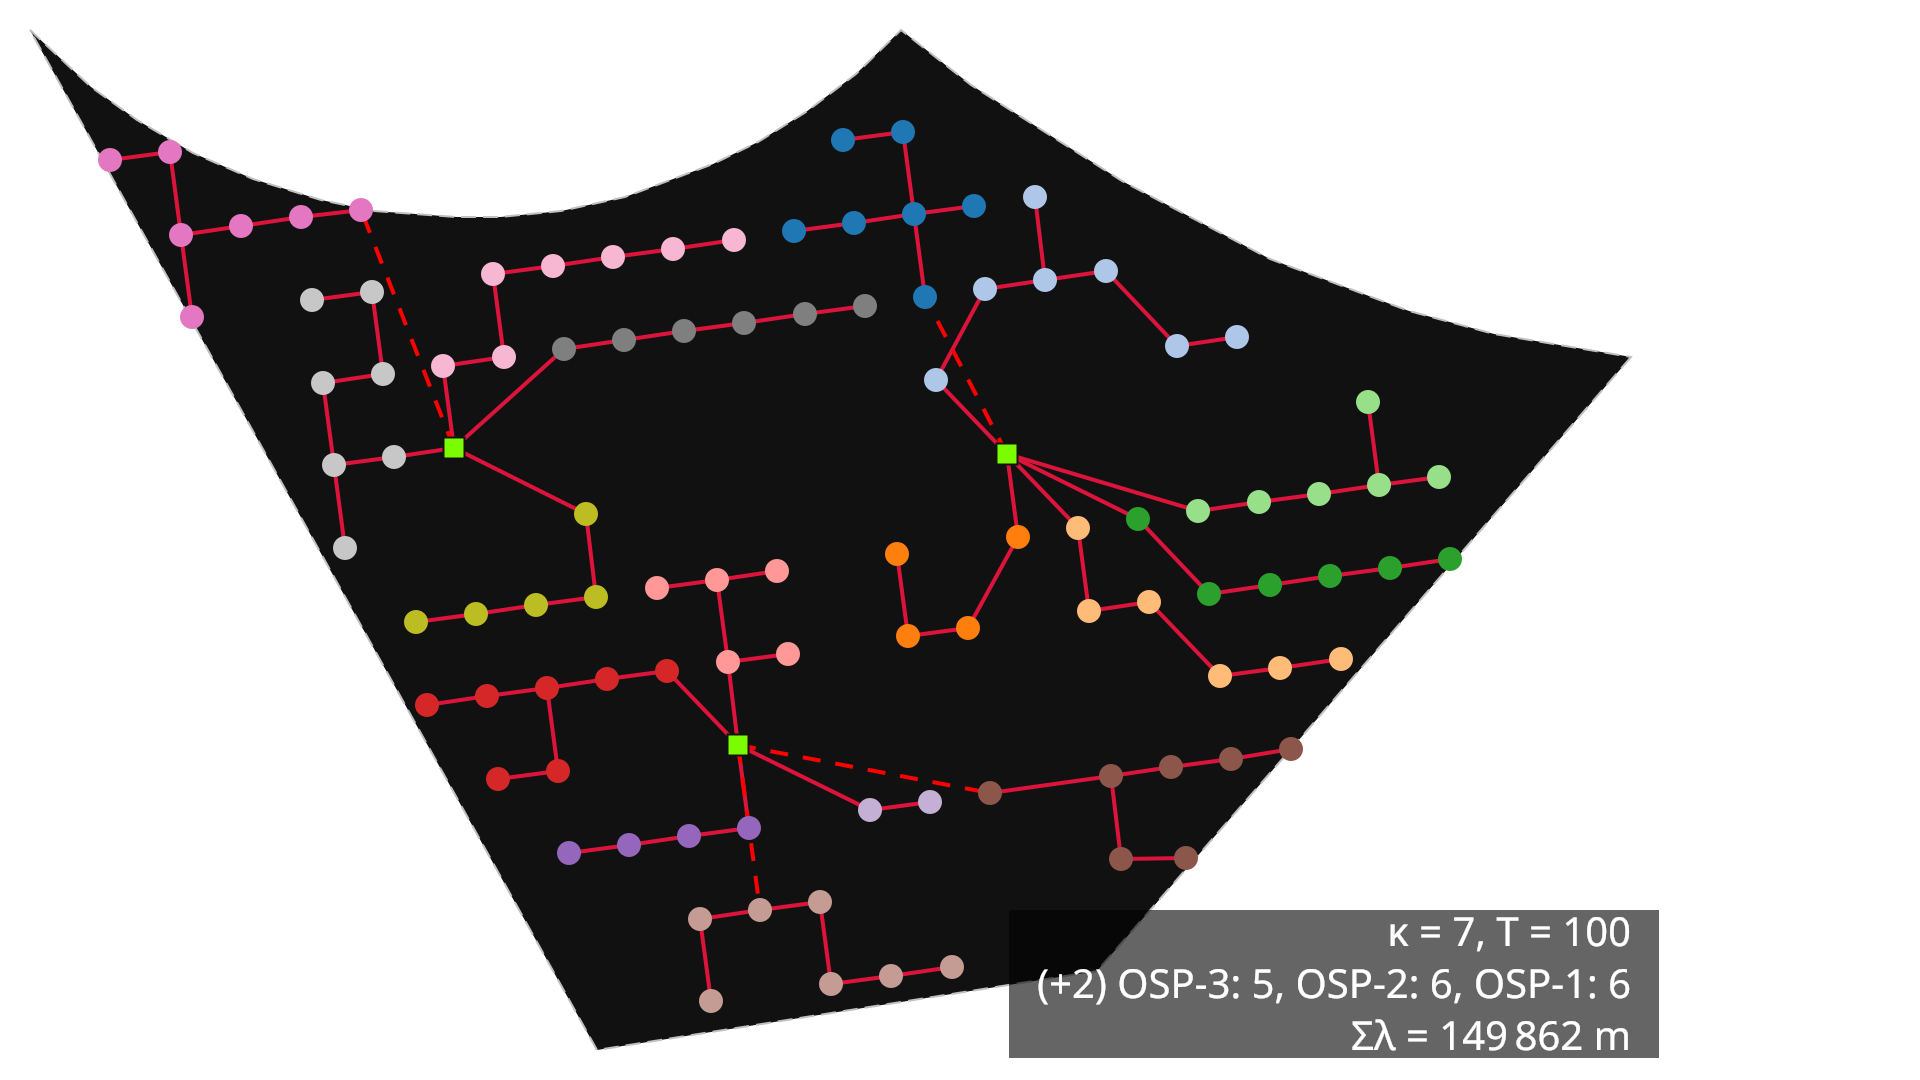

In [5]:
S_ew = constructor(A, capacity=7)
G_ew = G_from_S(S_ew, A)
svgplot(G_ew)

#### Get a meta-heuristic solution

(0.16, 0.02, 0.07)


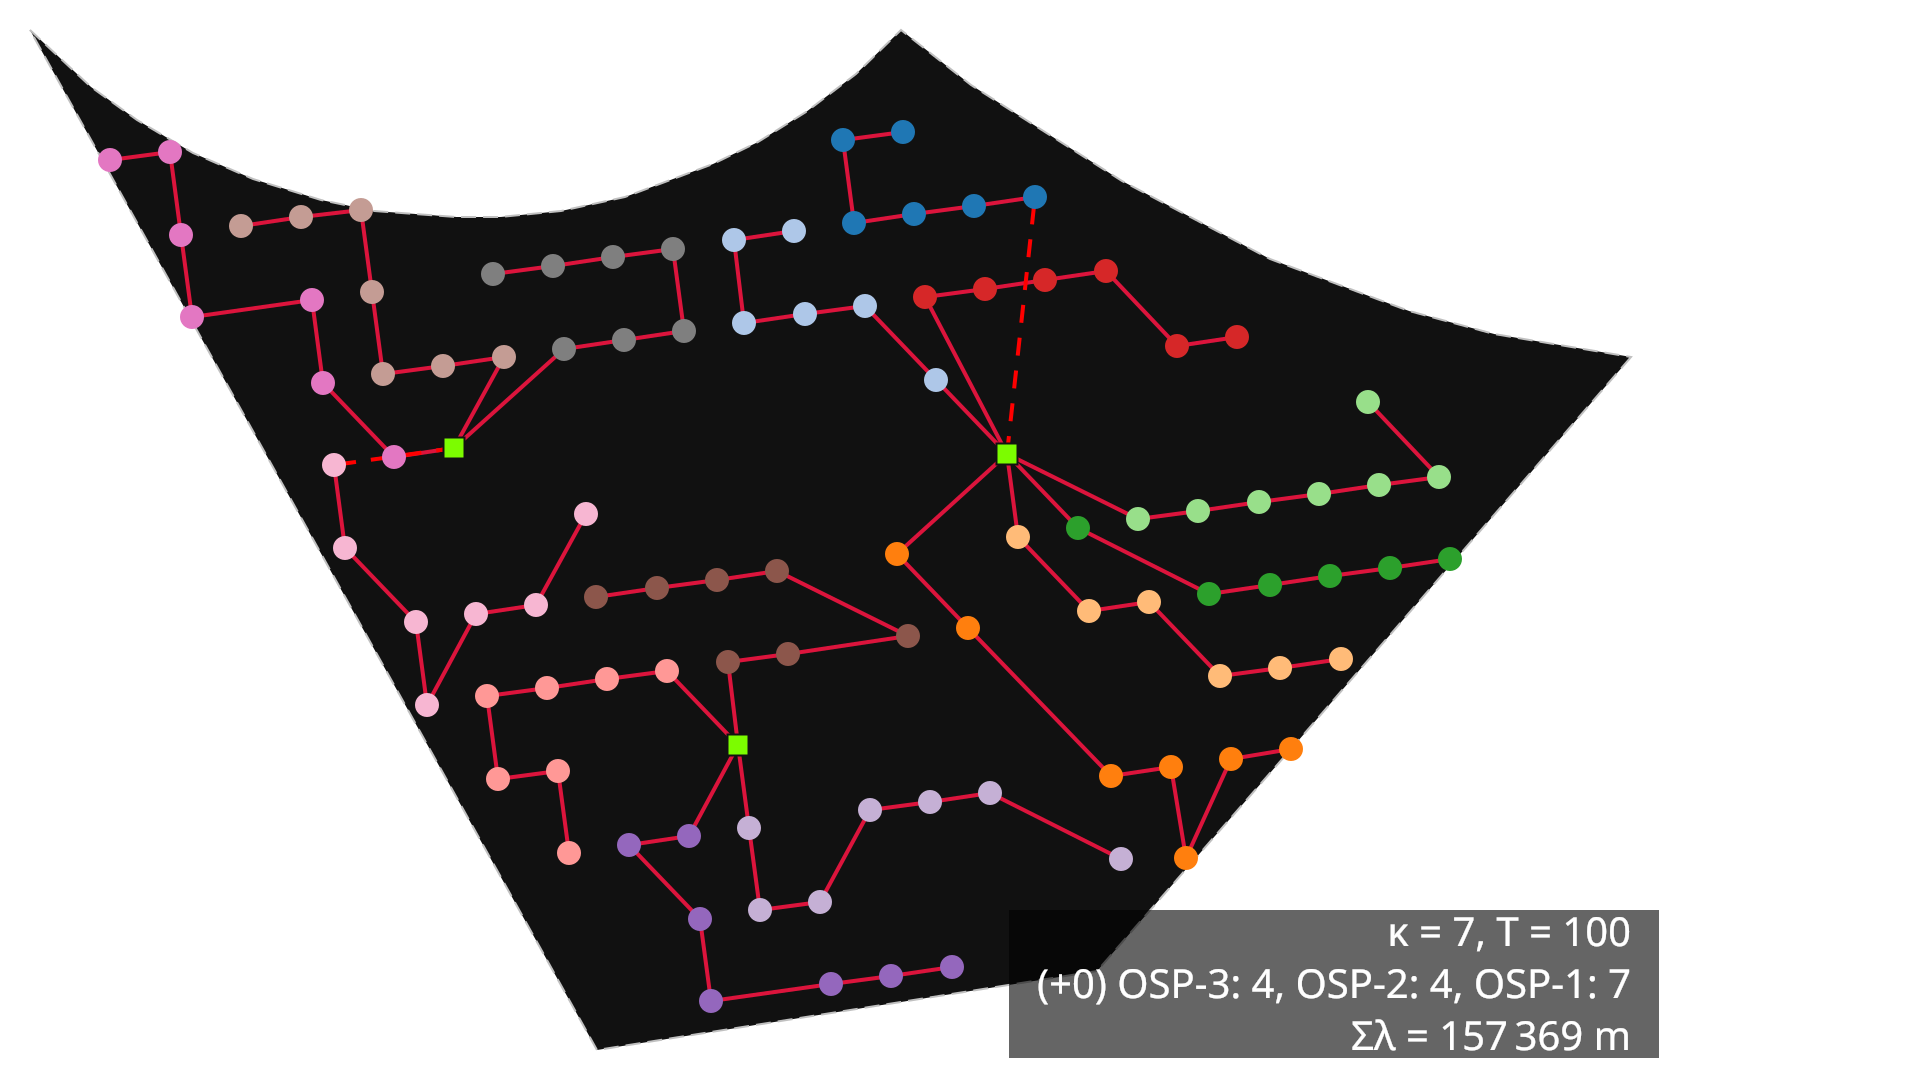

In [6]:
S_hgs = hgs_cvrp(
    as_normalized(A), capacity=7, time_limit=0.5, balanced=True
)
print(S_hgs.graph['solution_time'])
G_hgs = G_from_S(S_hgs, A)
svgplot(G_hgs)

#### Use MILP solver to refine solution

In [7]:
solver = solver_factory('ortools.cp_sat')

In [8]:
solver.set_problem(
    P, A, S_ew.graph['capacity'],
    ModelOptions(
        topology='branched',
        feeder_route='segmented',
        feeder_limit='unlimited'
    ), warmstart=S_ew
)

In [9]:
# required to get the log inside the notebook (goes only to console otherwise)
solver.log_callback = print

solver.solve(
    time_limit=40,
    mip_gap=0.005,
    verbose=True,
)

IntegerBoundsPreprocessor                              3527 rows, 2440 columns, 13320 entries with magnitude in [1.000000e+00, 7.000000e+00]
BoundPropagationPreprocessor                           3527 rows, 2440 columns, 13320 entries with magnitude in [1.000000e+00, 7.000000e+00]
ImpliedIntegerPreprocessor                             3527 rows, 2440 columns, 13320 entries with magnitude in [1.000000e+00, 7.000000e+00]
IntegerBoundsPreprocessor                              3527 rows, 2440 columns, 13320 entries with magnitude in [1.000000e+00, 7.000000e+00]
ReduceCostOverExclusiveOrConstraintPreprocessor        3527 rows, 2440 columns, 13320 entries with magnitude in [1.000000e+00, 7.000000e+00]

Scaling to pure integer problem.
Num integers: 1220/2440 (implied: 0 in_inequalities: 0 max_scaling: 0) [MIP] 
Maximum constraint coefficient relative error: 0
Maximum constraint worst-case activity error: 0
Constraint scaling factor range: [1, 1]

Starting CP-SAT solver v9.15.6755
Parameters:

SolutionInfo(runtime=40.040271, bound=142130.09784802853, objective=143300.10646896047, relgap=0.008164743556456244, termination='FEASIBLE')

In [10]:
S, G = solver.get_solution()

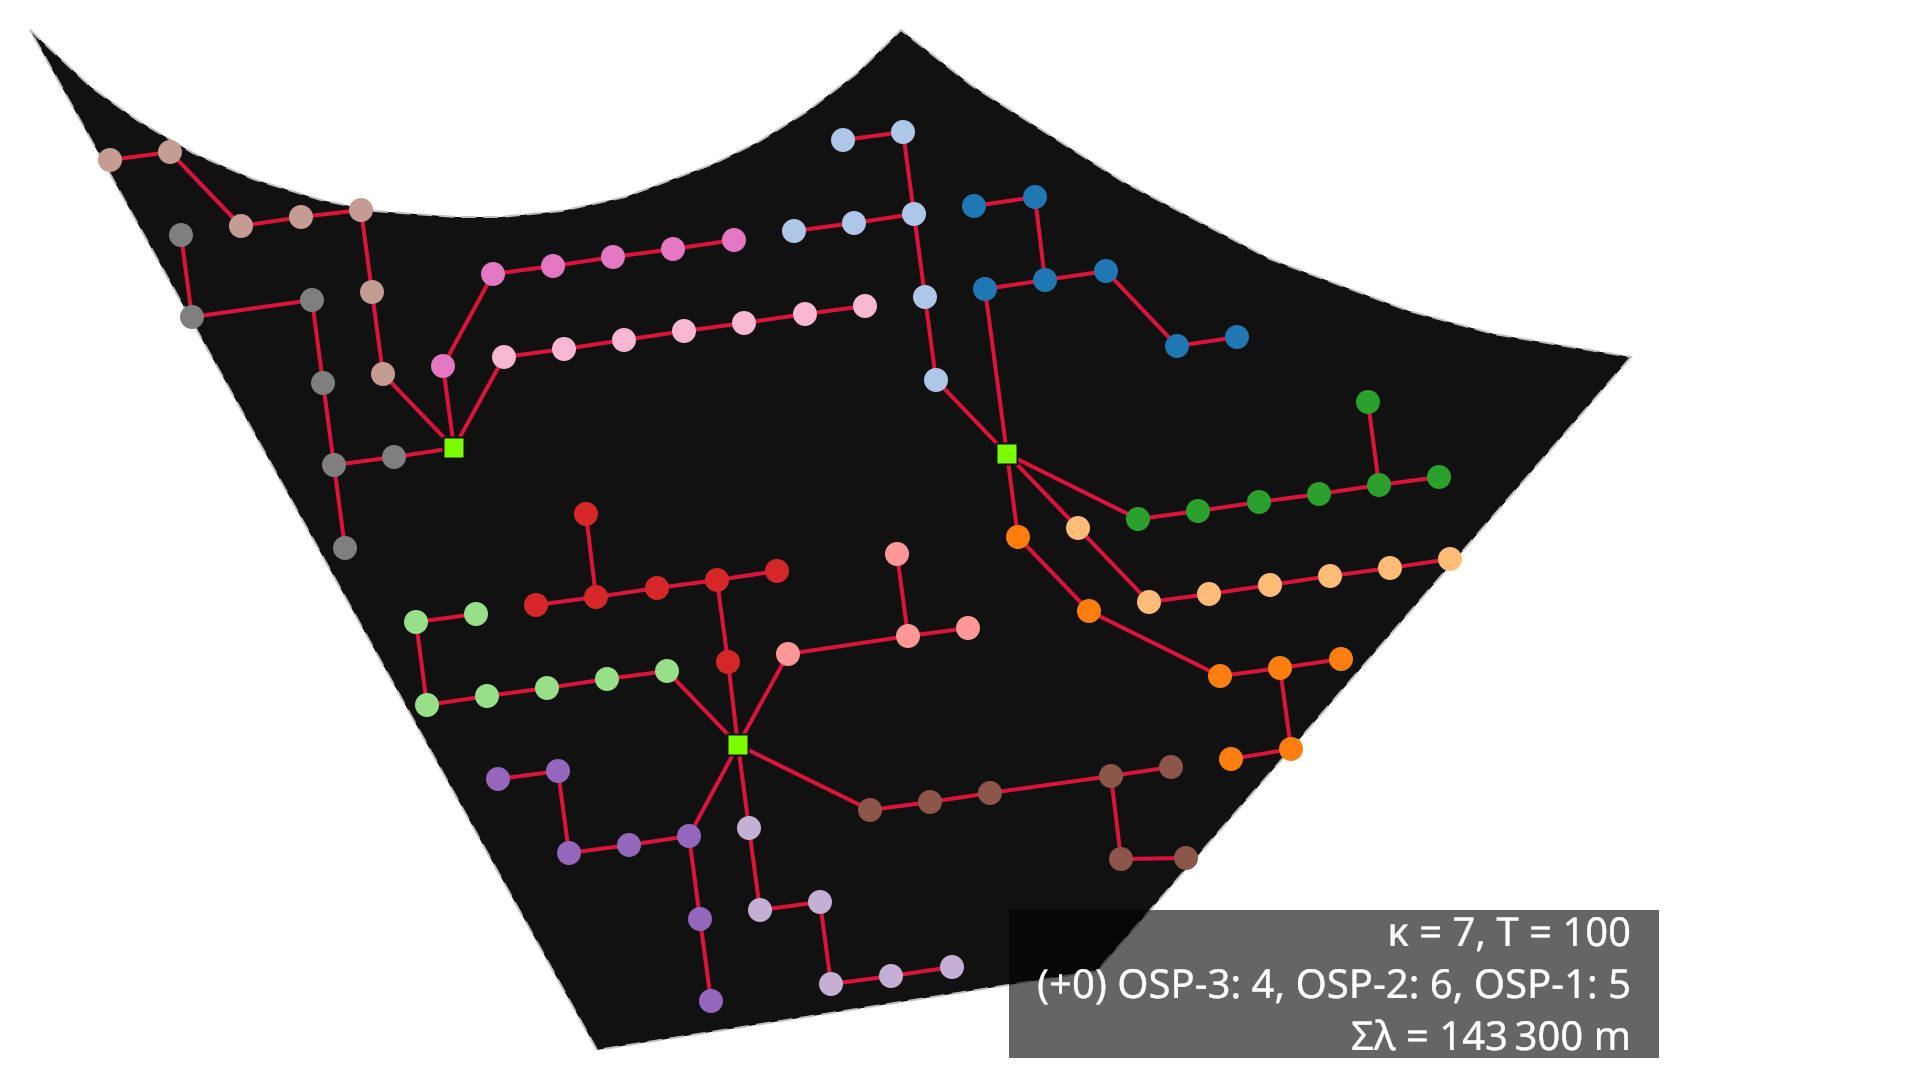

In [11]:
svgplot(G)

### Balanced subtrees

In [12]:
solver.set_problem(
    P, A, S_ew.graph['capacity'],
    ModelOptions(
        topology='branched',
        feeder_route='segmented',
        feeder_limit='minimum',
        balanced=True,
    ), warmstart=S_hgs
)

In [13]:
# required to get the log inside the notebook (goes only to console otherwise)
solver.log_callback = print

solver.solve(
    time_limit=40,
    mip_gap=0.005,
    verbose=True,
)

IntegerBoundsPreprocessor                              3827 rows, 2440 columns, 13920 entries with magnitude in [1.000000e+00, 7.000000e+00]
BoundPropagationPreprocessor                           3827 rows, 2440 columns, 13920 entries with magnitude in [1.000000e+00, 7.000000e+00]
ImpliedIntegerPreprocessor                             3827 rows, 2440 columns, 13920 entries with magnitude in [1.000000e+00, 7.000000e+00]
IntegerBoundsPreprocessor                              3827 rows, 2440 columns, 13920 entries with magnitude in [1.000000e+00, 7.000000e+00]
ReduceCostOverExclusiveOrConstraintPreprocessor        3827 rows, 2440 columns, 13920 entries with magnitude in [1.000000e+00, 7.000000e+00]

Scaling to pure integer problem.
Num integers: 1220/2440 (implied: 0 in_inequalities: 0 max_scaling: 0) [MIP] 
Maximum constraint coefficient relative error: 0
Maximum constraint worst-case activity error: 0
Constraint scaling factor range: [1, 1]

Starting CP-SAT solver v9.15.6755
Parameters:

SolutionInfo(runtime=40.056722, bound=142683.2677536973, objective=143698.7327195847, relgap=0.007066624365219654, termination='FEASIBLE')

In [14]:
S, G = solver.get_solution()

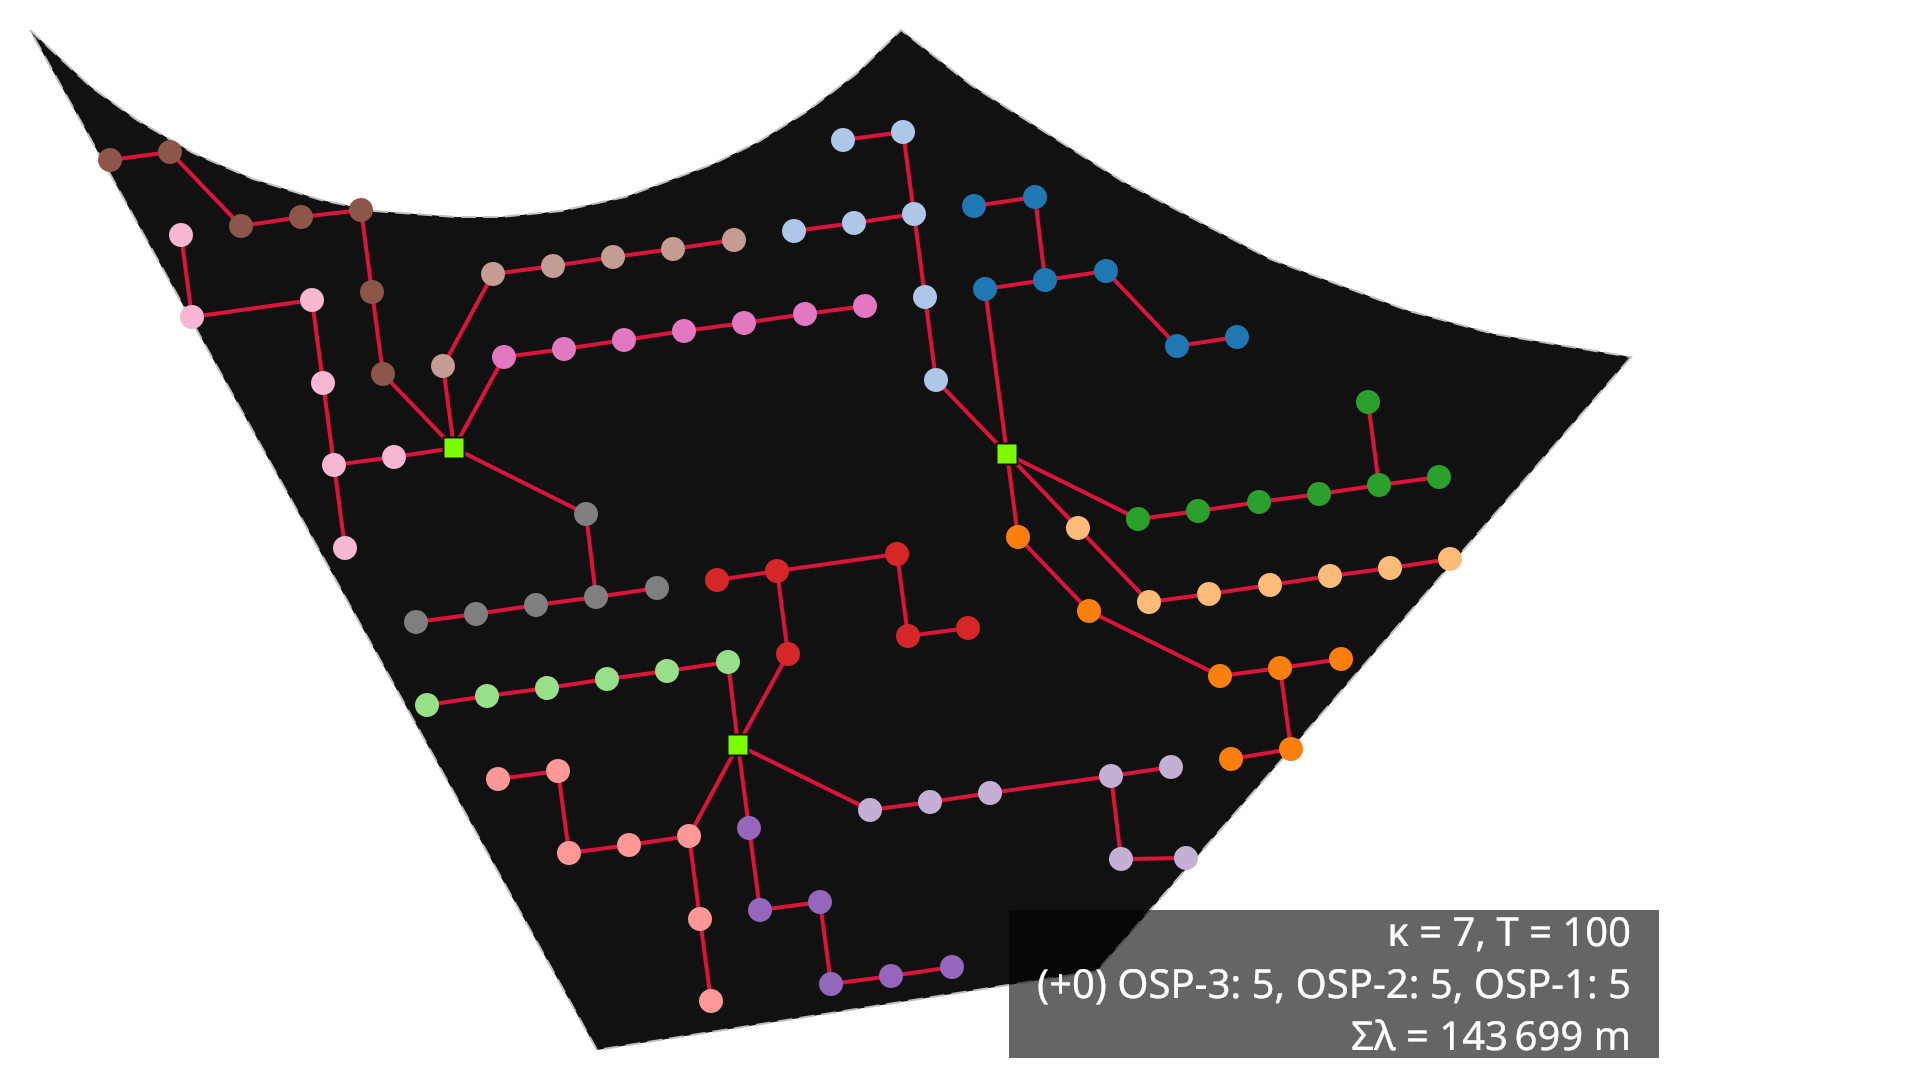

In [15]:
svgplot(G)